# RAFT (Retrieval Augmented Fine-Tuning) with Unsloth & LoRA

Notebook ini dibuat untuk melakukan fine-tuning model LLM menggunakan dataset RAFT (`raft_dataset_finalv1.jsonl` dan `raft_dataset_multi_oracle.jsonl`) dengan teknik LoRA (Low-Rank Adaptation) dan *library* Unsloth agar proses *training* jauh lebih cepat dan hemat memori.

### Mengapa RAFT Tahan Terhadap Distraktor?
Dalam paper jurnal **"RAFT: Adapting Language Model to Domain Specific RAG"** (Zhang et al., 2024), model tidak hanya dilatih untuk menjawab berdasarkan konteks yang relevan (Oracle), tetapi juga **sengaja diberikan dokumen distraktor (irrelevant/noise)**.
- Model dipaksa belajar melalui *Chain-of-Thought* (CoT) (dalam dataset Anda disebut `thought_process`) untuk memilah mana dokumen yang benar-benar relevan dan mana yang tidak.
- Untuk beberapa *training sample*, model bahkan dilatih untuk menolak menjawab jika tidak ada dokumen *oracle* sama sekali (100% distraktor).
- Hasilnya, model fine-tuning ini menjadi sangat robust (tahan uji) ketika di-deploy dalam sistem RAG nyata yang seringkali hasil *retrieval*-nya (dari Vector Database) kurang akurat atau mengandung banyak *noise*.

Referensi Jurnal:
- Zhang, D., et al. (2024). *RAFT: Adapting Language Model to Domain Specific RAG*. arXiv preprint arXiv:2403.10131. URL: https://arxiv.org/abs/2403.10131

In [1]:
# %%capture
# !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install --no-deps xformers trl peft accelerate bitsandbytes datasets

### STEP 1: Cek Lingkungan (GPU & Library)

In [2]:
import torch
import transformers
import trl

print("=" * 60)
print("CEK LINGKUNGAN")
print("=" * 60)
print(f"PyTorch version   : {torch.__version__}")
print(f"Transformers ver  : {transformers.__version__}")
print(f"TRL version       : {trl.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()}")
print(f"GPU count         : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}            : {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"  Total memory    : {props.total_memory / 1024**3:.2f} GB")
        print(f"  Compute cap     : {props.major}.{props.minor}")
print("=" * 60)

assert torch.cuda.is_available(), "CUDA tidak tersedia! Pastikan GPU terdeteksi."

/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CEK LINGKUNGAN
PyTorch version   : 2.11.0+cu128
Transformers ver  : 5.5.0
TRL version       : 0.24.0
CUDA available    : True
GPU count         : 1
GPU 0            : NVIDIA B200
  Total memory    : 178.36 GB
  Compute cap     : 10.0


## 1. Load Model dengan Unsloth & Konfigurasi LoRA
Kita akan menggunakan model `Llama-3-8B-Instruct` sebagai *base model*. Unsloth menyediakan model dalam format 4-bit secara bawaan untuk penghematan memori.

In [3]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 4096 
dtype = None # None agar mendeteksi otomatis (Float16 untuk T4, Bfloat16 untuk Ampere+)
load_in_4bit = False # Gunakan 4-bit quantization untuk menghemat memori GPU

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "../model/Meta-Llama-3.1-8B-Instruct", # Bisa diganti model lain seperti Mistral atau Qwen
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# Konfigurasi LoRA (Low-Rank Adaptation)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Rank LoRA. Disarankan: 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",], # Module standar untuk LLaMA/Mistral
    lora_alpha = 16,
    lora_dropout = 0, # Dropout 0 lebih optimal untuk Unsloth
    bias = "none",    # Gunakan "none" untuk Unsloth
    use_gradient_checkpointing = "unsloth", # True atau "unsloth" untuk memory sangat kecil
    random_state = 3407,
    use_rslora = False,  # Rank Stabilized LoRA
    loftq_config = None, # LoftQ
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/workspace/.venv/lib/python3.10/site-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [trl, transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:03<00:00, 90.14it/s] 
Unsloth: Will load ../model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


../model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.


Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


## 2. Persiapan & Formatting Dataset RAFT
Di sini kita akan memproses format dataset `raft_dataset_finalv1.jsonl` dan menyatukannya dalam struktur *prompt* instruksi. Model akan diajarkan untuk merangkai `<thought>` (Chain of Thought) terlebih dahulu untuk memilah dokumen distraktor sebelum memberikan jawaban akhir.

In [4]:
from datasets import load_dataset, concatenate_datasets

# --- Ganti path ini ke lokasi dataset jsonl Anda di Google Drive atau Local ---
dataset_path_1 = "../data/dataset/raft_dataset_finalv1.jsonl"
dataset_path_2 = "../data/dataset/raft_dataset_multi_oracle.jsonl"

try:
    # 1. Load masing-masing file secara terpisah
    ds1 = load_dataset("json", data_files=dataset_path_1, split="train")
    ds2 = load_dataset("json", data_files=dataset_path_2, split="train")
    
    # 2. Hapus kolom 'metadata_extra' dan 'validation' yang tipe datanya bentrok
    cols_to_remove = ["metadata_extra", "validation"]
    ds1 = ds1.remove_columns([c for c in cols_to_remove if c in ds1.column_names])
    ds2 = ds2.remove_columns([c for c in cols_to_remove if c in ds2.column_names])
    
    # 3. Gabungkan menjadi satu dataset yang bersih
    dataset = concatenate_datasets([ds1, ds2])
    print(f"Berhasil dimuat! Total data: {len(dataset)} baris.")
    
except Exception as e:
    print(f"Error: {e}")

# ==========================================
# BAGIAN PROMPT DAN FORMATTING
# ==========================================

raft_prompt = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa. 
Diberikan sejumlah dokumen referensi, analisislah dokumen tersebut untuk mencari jawaban yang tepat. 
Tuliskan proses berpikir Anda di dalam tag <thought>...</thought> dengan menjelaskan dokumen mana yang relevan dan tidak relevan (distraktor). Setelah itu, berikan jawaban akhir Anda berdasarkan hasil analisis tersebut.<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: {instruction}

Dokumen Referensi:
{documents}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

<thought>
{thought_process}
</thought>

{completion}"""

EOS_TOKEN = tokenizer.eos_token # Harus menambahkan EOS_TOKEN di akhir

def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    docs_lists = examples["documents"]
    thought_processes = examples["thought_process"]
    completions = examples["completion"]
    texts = []
    
    for instruction, docs, thought, completion in zip(instructions, docs_lists, thought_processes, completions):
        # Format ulang list dokumen menjadi bentuk teks terstruktur
        formatted_docs = ""
        for idx, doc in enumerate(docs):
            formatted_docs += f"<doc id=\"{idx+1}\">\n{doc}\n</doc>\n\n"
            
        # Apabila thought tidak ada (bisa terjadi jika belum di-generate secara utuh), skip atau buat default.
        thought_text = thought if thought else "Tidak ada dokumen yang relevan."
        
        text = raft_prompt.format(
            instruction=instruction, 
            documents=formatted_docs.strip(), 
            thought_process=thought_text, 
            completion=completion
        ) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }

if 'dataset' in locals():
    # Jalankan mapping data
    dataset = dataset.map(formatting_prompts_func, batched = True, remove_columns=dataset.column_names)
    print("\n--- Contoh Hasil Format Prompt Baris Pertama ---\n")
    print(dataset[0]["text"])


Berhasil dimuat! Total data: 543 baris.

--- Contoh Hasil Format Prompt Baris Pertama ---

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa. 
Diberikan sejumlah dokumen referensi, analisislah dokumen tersebut untuk mencari jawaban yang tepat. 
Tuliskan proses berpikir Anda di dalam tag <thought>...</thought> dengan menjelaskan dokumen mana yang relevan dan tidak relevan (distraktor). Setelah itu, berikan jawaban akhir Anda berdasarkan hasil analisis tersebut.<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: Apa sih yang dimaksud dengan pemerintahan desa itu?

Dokumen Referensi:
<doc id="1">
pasal 12

(2) kartu tanda penduduk atau surat keterangan bertempat tinggal paling singkat 1 (satu) tahun sebelum pendaftaran dari rukun tetangga atau rukun warga setempat;
</doc>

<doc id="2">
pasal 1

2. daerah adalah kabupaten bandung.
</doc>

<doc id="3">
pasal 1

2. pemeri

## 3. Training Menggunakan SFTTrainer dari TRL

In [5]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

if 'dataset' in locals():
    sft_config = SFTConfig(
        dataset_text_field = "text",
        max_seq_length = max_seq_length,
        dataset_num_proc = 2,
        packing = True, # Dapat diset ke True untuk percepatan training sequence panjang
        
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 4,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    )

    # 3. SFTTrainer sekarang menjadi jauh lebih bersih
    trainer = SFTTrainer(
        model = model,
        tokenizer = tokenizer,
        train_dataset = dataset,
        args = sft_config,
    )
    
    # Mulai training!
    trainer_stats = trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 126 | Num Epochs = 4 | Total steps = 64
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,1.524149
2,1.395670
3,1.474750
4,1.441096
5,1.453004
6,1.216597
7,1.068117
8,1.111229
9,1.029993
10,0.969558


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-64/tokenizer_config.json.


## 4. Inference Model yang Sudah Di-Finetune
Mari kita tes model kita!

In [6]:
FastLanguageModel.for_inference(model) # Enable inference mode bawaan Unsloth agar cepat

test_instruction = "Berapa tahun masa jabatan Kepala Desa menurut peraturan?"
test_docs = """<doc id="1">
Pasal 2
Pemberdayaan masyarakat sangat penting.
</doc>

<doc id="2">
Pasal 39
Kepala Desa memegang jabatan selama 6 (enam) tahun terhitung sejak tanggal pelantikan.
</doc>
"""

inputs = tokenizer(
[
    raft_prompt.format(
        instruction=test_instruction,
        documents=test_docs,
        thought_process="", # Dikosongkan agar digenerate oleh model
        completion=""
    )
], return_tensors = "pt").to("cuda")

outputs = model.generate(**inputs, max_new_tokens = 256, use_cache = True)
print(tokenizer.batch_decode(outputs, skip_special_tokens = False)[0])

Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


<|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa. 
Diberikan sejumlah dokumen referensi, analisislah dokumen tersebut untuk mencari jawaban yang tepat. 
Tuliskan proses berpikir Anda di dalam tag <thought>...</thought> dengan menjelaskan dokumen mana yang relevan dan tidak relevan (distraktor). Setelah itu, berikan jawaban akhir Anda berdasarkan hasil analisis tersebut.<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: Berapa tahun masa jabatan Kepala Desa menurut peraturan?

Dokumen Referensi:
<doc id="1">
Pasal 2
Pemberdayaan masyarakat sangat penting.
</doc>

<doc id="2">
Pasal 39
Kepala Desa memegang jabatan selama 6 (enam) tahun terhitung sejak tanggal pelantikan.
</doc>

<|eot_id|><|start_header_id|>assistant<|end_header_id|>

<thought>

</thought>

Berdasarkan Pasal 39, masa jabatan Kepala Desa adalah 6 (enam) tahun terhitung sejak tanggal 


>>> Total Waktu Training: 25.95 menit
>>> VRAM Maksimal Terpakai: 0.0 GB / 191.0 GB
>>> Grafik visualisasi berhasil disimpan di 'outputs_lora/vram_and_training_stats.png'


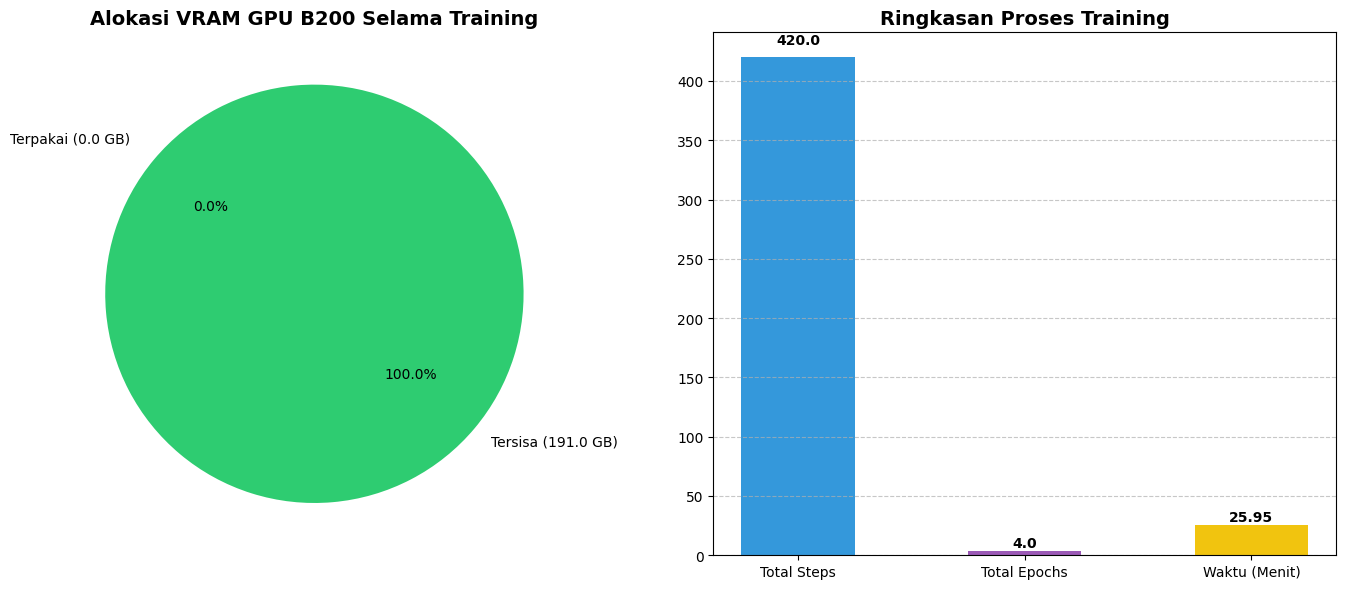

In [10]:
import matplotlib.pyplot as plt

# 1. Ambil data statistik dari Unsloth trainer_stats
metrics = trainer_stats.metrics
total_time_mins = round(metrics.get("train_runtime", 0) / 60, 2)
vram_used_gb    = round(metrics.get("train_mem_allocated_max", 0) / (1024**3), 2)

# Mengasumsikan spesifikasi GPU B200 Anda (191 GB)
vram_total_gb   = 191.0  
vram_free_gb    = round(vram_total_gb - vram_used_gb, 2)

print(f"\n>>> Total Waktu Training: {total_time_mins} menit")
print(f">>> VRAM Maksimal Terpakai: {vram_used_gb} GB / {vram_total_gb} GB")

# 2. Membuat Grafik Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafik 1: Alokasi VRAM GPU B200 (Pie Chart) ---
labels_vram = [f'Terpakai ({vram_used_gb} GB)', f'Tersisa ({vram_free_gb} GB)']
sizes_vram  = [vram_used_gb, vram_free_gb]
colors_vram = ['#ff4d4d', '#2ecc71']

ax1.pie(sizes_vram, labels=labels_vram, autopct='%1.1f%%', startangle=140, colors=colors_vram, explode=(0.05, 0))
ax1.set_title("Alokasi VRAM GPU B200 Selama Training", fontsize=14, fontweight='bold')

# --- Grafik 2: Ringkasan Metrik (Bar Chart) ---
metrics_labels = ['Total Steps', 'Total Epochs', 'Waktu (Menit)']
metrics_values = [metrics.get("global_step", 420), sft_config.num_train_epochs, total_time_mins]
colors_bar    = ['#3498db', '#9b59b6', '#f1c40f']

bars = ax2.bar(metrics_labels, metrics_values, color=colors_bar, width=0.5)
ax2.set_title("Ringkasan Proses Training", fontsize=14, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan angka di atas setiap bar chart
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f"{yval}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

# 3. Simpan grafik sebagai gambar
plt.savefig("outputs_lora/vram_and_training_stats.png", dpi=300)
print(">>> Grafik visualisasi berhasil disimpan di 'outputs_lora/vram_and_training_stats.png'")
plt.show()


>>> [INFO] Grafik Training Loss sedang dibuat...
>>> [INFO] Waktu Aktual Training: 25 menit 57 detik
>>> [SUKSES] Grafik berhasil disimpan di 'outputs_lora/training_loss_curve.png'


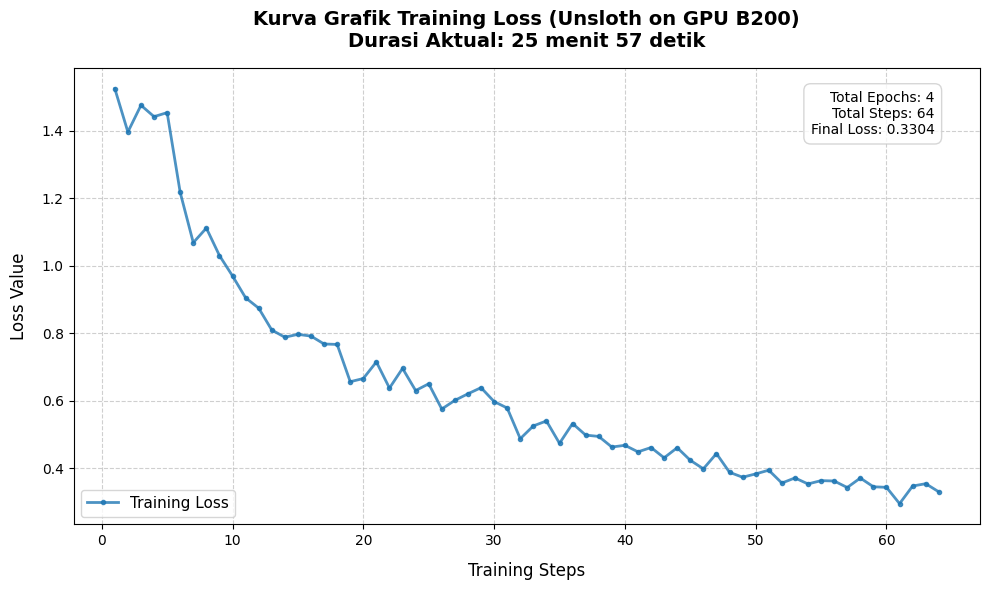

In [11]:
import matplotlib.pyplot as plt

# 1. Ambil log history untuk visualisasi Training Loss
log_history = trainer.state.log_history

# Saring data untuk mengambil langkah yang berisi 'loss' (bukan evaluasi)
steps = [log.get("step") for log in log_history if "loss" in log]
losses = [log.get("loss") for log in log_history if "loss" in log]

# 2. Ambil waktu aktual dari trainer_stats
metrics = trainer_stats.metrics
total_seconds = metrics.get("train_runtime", 0)

# Konversi detik ke jam, menit, dan detik
hours = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

# Format teks durasi waktu aktual
waktu_aktual = f"{hours} jam {minutes} menit {seconds} detik" if hours > 0 else f"{minutes} menit {seconds} detik"

print(f"\n>>> [INFO] Grafik Training Loss sedang dibuat...")
print(f">>> [INFO] Waktu Aktual Training: {waktu_aktual}")

# 3. Membuat Grafik Visualisasi Training Loss
plt.figure(figsize=(10, 6))

# Plot kurva loss (Warna biru tua khas visualisasi profesional)
plt.plot(steps, losses, label="Training Loss", color="#1f77b4", linewidth=2, marker='o', markersize=3, alpha=0.8)

# Kostumisasi tampilan grafik
plt.title(f"Kurva Grafik Training Loss (Unsloth on GPU B200)\nDurasi Aktual: {waktu_aktual}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Training Steps", fontsize=12, labelpad=10)
plt.ylabel("Loss Value", fontsize=12, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

# Tambahkan catatan teks info di dalam grafik (opsional)
info_text = f"Total Epochs: {sft_config.num_train_epochs}\nTotal Steps: {max(steps) if steps else MAX_STEPS}\nFinal Loss: {losses[-1]:.4f}"
plt.gca().text(0.95, 0.95, info_text, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#ccc'))

plt.tight_layout()

# 4. Simpan dan Tampilkan Gambar
plt.savefig("outputs_lora/training_loss_curve.png", dpi=300)
print(">>> [SUKSES] Grafik berhasil disimpan di 'outputs_lora/training_loss_curve.png'")
plt.show()


## 5. Menyimpan LoRA Adapter
Setelah puas dengan hasil *fine-tuning*, kita bisa menyimpan model atau adapter LoRA-nya saja.

In [7]:
model.save_pretrained("lora_adapter_raft_perdes")
tokenizer.save_pretrained("model_merged_raft_perdes")

# Jika ingin push ke Huggingface Hub
# model.push_to_hub("your_name/lora_raft_model", token = "...")
# tokenizer.push_to_hub("your_name/lora_raft_model", token = "...")

# Anda bisa meload kembali adapter tersebut ke depannya dengan menggunakan:
# model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name = "lora_raft_model",
#     max_seq_length = max_seq_length,
#     dtype = dtype,
#     load_in_4bit = load_in_4bit,
# )

Unsloth: Restored added_tokens_decoder metadata in model_merged_raft_perdes/tokenizer_config.json.


('model_merged_raft_perdes/tokenizer_config.json',
 'model_merged_raft_perdes/chat_template.jinja',
 'model_merged_raft_perdes/tokenizer.json')

In [12]:
# Ini cara yang BENAR untuk menyimpan Merged Model (digabung penuh)
model.save_pretrained_merged("model_merged_raft_perdes", tokenizer, save_method="merged_16bit")


Detected local model directory: /workspace/model/Meta-Llama-3.1-8B-Instruct
Found HuggingFace hub cache directory: /home/kel07/.cache/huggingface/hub


Unsloth: Preparing safetensor model files:  25%|██▌       | 1/4 [00:01<00:03,  1.01s/it]

Copied model-00004-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files:  50%|█████     | 2/4 [00:04<00:05,  2.70s/it]

Copied model-00003-of-00004.safetensors from local model directory


...

Copied model-00002-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [00:12<00:00,  3.22s/it]


Copied model-00001-of-00004.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [00:43<00:00, 10.87s/it]


Unsloth: Merge process complete. Saved to `/workspace/notebooks/model_merged_raft_perdes`
